# Exploratory Data Analysis — NYC Yellow Taxi

## Objetivo

Analizar los patrones de movilidad de los viajes de Yellow Taxi durante julio de 2026.

El análisis se enfocará en:

- demanda por día y hora;
- diferencias entre días laborales y fines de semana;
- duración y distancia de los viajes;
- comportamiento de tarifas y propinas;
- velocidad promedio según período;
- zonas de origen y destino con mayor actividad;
- identificación de patrones y anomalías relevantes.

Para las métricas sensibles a valores extremos se utilizarán filtros de calidad y estadísticas robustas cuando corresponda.

In [1]:
# Preparar el entorno
from pathlib import Path
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import gc

# Evitar notación científica y mostrar números con 2 decimales
pd.options.display.float_format = "{:,.2f}".format

# Definir ruta del dataset
ruta_features = Path(
    "../data/processed/yellow_tripdata_2026-07_features.parquet"
)

# Abrir archivo Parquet
archivo = pq.ParquetFile(ruta_features)

print("Archivo encontrado:", ruta_features.exists())
print("Filas:", archivo.metadata.num_rows)
print("Columnas:", archivo.metadata.num_columns)
print("Row Groups:", archivo.metadata.num_row_groups)

Archivo encontrado: True
Filas: 3530109
Columnas: 40
Row Groups: 4


In [2]:
# Calcular la demanda de taxis por día
viajes_por_dia = []

for i in range(archivo.metadata.num_row_groups):

    bloque = archivo.read_row_group(
        i,
        columns=["tpep_pickup_datetime"]
    ).to_pandas()

    bloque["fecha"] = bloque["tpep_pickup_datetime"].dt.date

    conteo = bloque.groupby("fecha").size()

    viajes_por_dia.append(conteo)

    del bloque
    gc.collect()

viajes_por_dia = (
    pd.concat(viajes_por_dia, axis=1)
    .fillna(0)
    .sum(axis=1)
    .astype(int)
    .sort_index()
)

viajes_por_dia

fecha
2008-12-30         1
2026-06-30         7
2026-07-01    112714
2026-07-02    108963
2026-07-03     88370
2026-07-04     83835
2026-07-05     83429
2026-07-06    100365
2026-07-07    102068
2026-07-08    107937
2026-07-09    116199
2026-07-10    114257
2026-07-11    121828
2026-07-12    109184
2026-07-13     99046
2026-07-14    119562
2026-07-15    135900
2026-07-16    131793
2026-07-17    122243
2026-07-18    131429
2026-07-19    120757
2026-07-20    111178
2026-07-21    116621
2026-07-22    126613
2026-07-23    124846
2026-07-24    117459
2026-07-25    122151
2026-07-26    113875
2026-07-27    102828
2026-07-28    114361
2026-07-29    119582
2026-07-30    129806
2026-07-31    120864
2026-08-01         8
2026-08-02        12
2026-08-03         6
2026-08-05        12
dtype: int64

In [3]:
# Analizar la demanda diaria correspondiente a julio de 2026
inicio = pd.Timestamp("2026-07-01").date()
fin = pd.Timestamp("2026-07-31").date()

viajes_julio_por_dia = viajes_por_dia[
    (viajes_por_dia.index >= inicio) &
    (viajes_por_dia.index <= fin)
]

print("Días analizados:", len(viajes_julio_por_dia))
print("Viajes en julio:", viajes_julio_por_dia.sum())

print("\nMayor demanda:")
print(viajes_julio_por_dia.idxmax(), viajes_julio_por_dia.max())

print("\nMenor demanda:")
print(viajes_julio_por_dia.idxmin(), viajes_julio_por_dia.min())

Días analizados: 31
Viajes en julio: 3530063

Mayor demanda:
2026-07-15 135900

Menor demanda:
2026-07-05 83429


In [4]:
# Resumen estadístico de la demanda diaria
viajes_julio_por_dia.describe()

count        31.00
mean    113,873.00
std      13,258.34
min      83,429.00
25%     108,450.00
50%     116,199.00
75%     121,989.50
max     135,900.00
dtype: float64

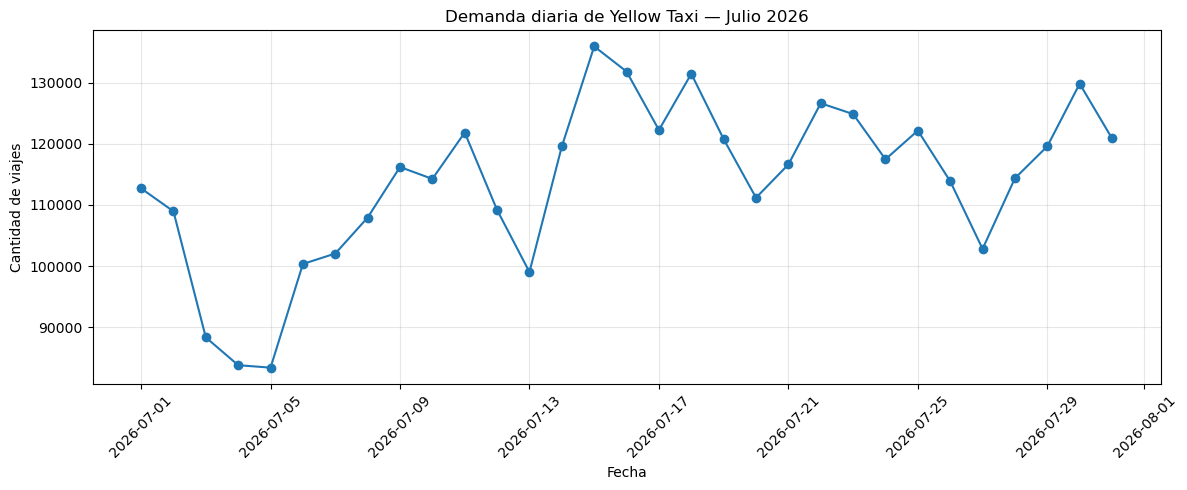

In [5]:
# Visualizar la evolución de la demanda diaria durante julio
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    viajes_julio_por_dia.index,
    viajes_julio_por_dia.values,
    marker="o"
)

plt.title("Demanda diaria de Yellow Taxi — Julio 2026")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de viajes")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretación — Demanda diaria

La demanda diaria presenta variaciones importantes a lo largo de julio de 2026.

El mayor volumen se registró el **15 de julio**, con aproximadamente **135.900 viajes**, mientras que el menor se observó el **5 de julio**, con cerca de **83.429 viajes**.

Después de la caída observada durante los primeros días del mes, la demanda se recupera y se mantiene generalmente por encima de los **100.000 viajes diarios** durante el resto de julio.

In [6]:
# Analizar cómo cambia la demanda según el día de la semana
demanda_dia_semana = (
    viajes_julio_por_dia
    .rename("viajes")
    .reset_index()
)

demanda_dia_semana["fecha"] = pd.to_datetime(
    demanda_dia_semana["fecha"]
)

demanda_dia_semana["dia_semana"] = (
    demanda_dia_semana["fecha"].dt.day_name()
)

orden_dias = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

resumen_dia_semana = (
    demanda_dia_semana
    .groupby("dia_semana")["viajes"]
    .agg(["mean", "median", "min", "max", "std", "count"])
    .reindex(orden_dias)
)

resumen_dia_semana.round(0)

,mean,median,min,max,std,count
dia_semana,,,,,,
Monday,"103,354.00","101,596.00",99046,111178,"5,446.00",4
Tuesday,"113,153.00","115,491.00",102068,119562,"7,691.00",4
Wednesday,"120,549.00","119,582.00",107937,135900,"11,111.00",5
Thursday,"122,321.00","124,846.00",108963,131793,"9,592.00",5
Friday,"112,639.00","117,459.00",88370,122243,"13,917.00",5
Saturday,"114,811.00","121,990.00",83835,131429,"21,125.00",4
Sunday,"106,811.00","111,530.00",83429,120757,"16,297.00",4


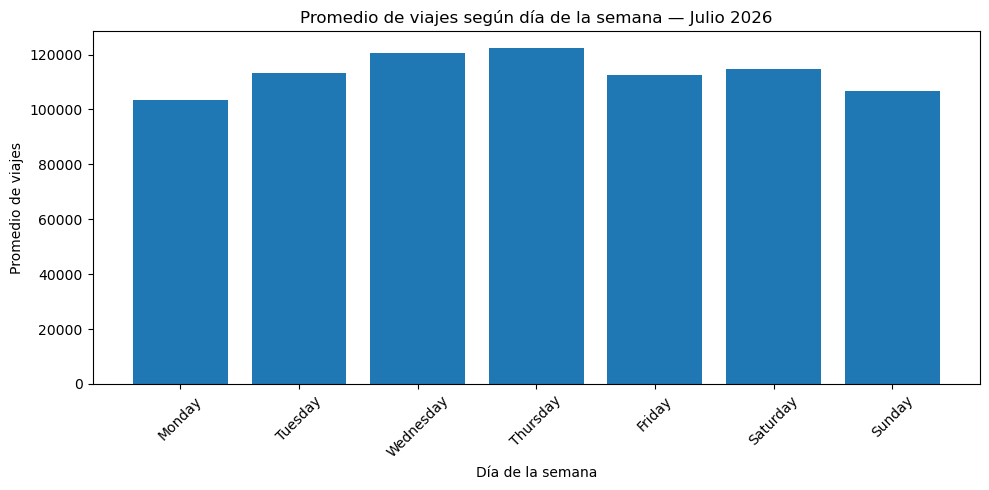

In [7]:
# Visualizar el promedio de viajes según el día de la semana
promedio_semana = resumen_dia_semana["mean"]

plt.figure(figsize=(10, 5))

plt.bar(
    promedio_semana.index,
    promedio_semana.values
)

plt.title("Promedio de viajes según día de la semana — Julio 2026")
plt.xlabel("Día de la semana")
plt.ylabel("Promedio de viajes")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretación — Demanda por día de la semana

La demanda promedio más alta se registra los **jueves**, con aproximadamente **122.321 viajes diarios**, seguida por los miércoles con cerca de **120.549 viajes**.

Los **lunes presentan la menor demanda promedio**, con aproximadamente **103.354 viajes**, mientras que los domingos también muestran un nivel relativamente bajo.

En general, la demanda aumenta entre lunes y jueves y luego disminuye hacia el final de la semana.

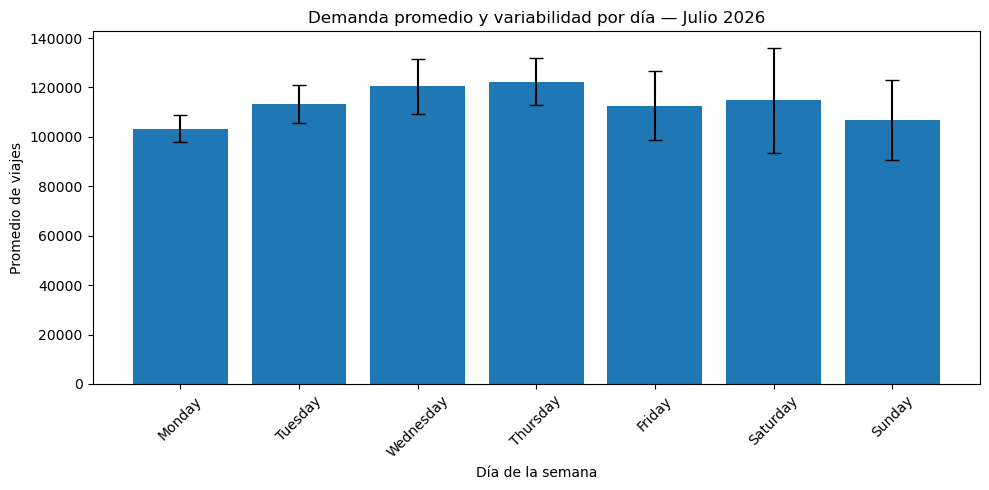

In [8]:
# Visualizar la demanda promedio y su variabilidad según el día de la semana
plt.figure(figsize=(10, 5))

plt.bar(
    resumen_dia_semana.index,
    resumen_dia_semana["mean"],
    yerr=resumen_dia_semana["std"],
    capsize=5
)

plt.title("Demanda promedio y variabilidad por día — Julio 2026")
plt.xlabel("Día de la semana")
plt.ylabel("Promedio de viajes")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Variabilidad de la demanda por día de la semana

Los lunes presentan la menor variabilidad en la demanda, mientras que los sábados muestran la mayor.

Los sábados registran un promedio de **114.811 viajes diarios**, con una desviación estándar de aproximadamente **21.125 viajes**.

Además, la demanda de los sábados presenta un rango amplio, desde un mínimo de **83.835** hasta un máximo de **131.429 viajes**, lo que indica una variabilidad considerable entre los distintos sábados de julio.

In [9]:
# Revisar la demanda de cada sábado de julio
sabados = demanda_dia_semana[
    demanda_dia_semana["dia_semana"] == "Saturday"
][["fecha", "viajes"]]

sabados

,fecha,viajes
3,2026-07-04,83835
10,2026-07-11,121828
17,2026-07-18,131429
24,2026-07-25,122151


In [10]:
# Comparar la variabilidad de los sábados con y sin el 4 de julio
print("TODOS LOS SÁBADOS")
print(sabados["viajes"].describe())

sabados_sin_4jul = sabados[
    sabados["fecha"] != pd.Timestamp("2026-07-04")
]

print("\nSIN EL 4 DE JULIO")
print(sabados_sin_4jul["viajes"].describe())

TODOS LOS SÁBADOS
count         4.00
mean    114,810.75
std      21,124.90
min      83,835.00
25%     112,329.75
50%     121,989.50
75%     124,470.50
max     131,429.00
Name: viajes, dtype: float64

SIN EL 4 DE JULIO
count         3.00
mean    125,136.00
std       5,452.29
min     121,828.00
25%     121,989.50
50%     122,151.00
75%     126,790.00
max     131,429.00
Name: viajes, dtype: float64


In [11]:
# Calcular la demanda de viajes según la hora del día
viajes_por_hora = []

for i in range(archivo.metadata.num_row_groups):

    bloque = archivo.read_row_group(
        i,
        columns=["tpep_pickup_datetime", "pickup_hour"]
    ).to_pandas()

    # Solo julio de 2026
    mascara_julio = (
        (bloque["tpep_pickup_datetime"] >= "2026-07-01") &
        (bloque["tpep_pickup_datetime"] < "2026-08-01")
    )

    bloque = bloque.loc[mascara_julio]

    conteo = bloque.groupby("pickup_hour").size()
    viajes_por_hora.append(conteo)

    del bloque
    gc.collect()

viajes_por_hora = (
    pd.concat(viajes_por_hora, axis=1)
    .fillna(0)
    .sum(axis=1)
    .astype(int)
    .sort_index()
)

viajes_por_hora

pickup_hour
0     114775
1      74759
2      50303
3      35915
4      30592
5      33365
6      58932
7      96428
8     139463
9     147672
10    147716
11    162464
12    176096
13    188392
14    200917
15    200657
16    211509
17    237095
18    243314
19    214134
20    198691
21    207560
22    197724
23    161590
dtype: int64

In [12]:
# Calcular la cantidad y el porcentaje de viajes por hora
porcentaje_por_hora = (
    viajes_por_hora / viajes_por_hora.sum() * 100
)

resumen_horario = pd.DataFrame({
    "viajes": viajes_por_hora,
    "porcentaje": porcentaje_por_hora
})

resumen_horario.round(2)

,viajes,porcentaje
pickup_hour,,
0,114775,3.25
1,74759,2.12
2,50303,1.42
3,35915,1.02
4,30592,0.87
5,33365,0.95
6,58932,1.67
7,96428,2.73
8,139463,3.95


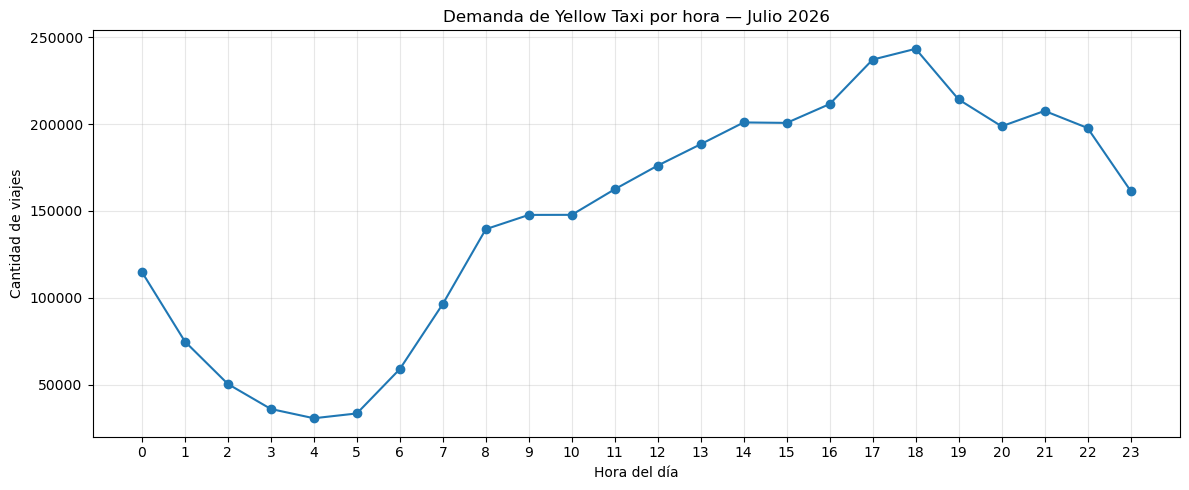

In [13]:
# Visualizar la evolución de la demanda según la hora del día
plt.figure(figsize=(12, 5))

plt.plot(
    viajes_por_hora.index,
    viajes_por_hora.values,
    marker="o"
)

plt.title("Demanda de Yellow Taxi por hora — Julio 2026")
plt.xlabel("Hora del día")
plt.ylabel("Cantidad de viajes")

plt.xticks(range(24))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretación — Demanda por hora

La demanda presenta su nivel más bajo durante la madrugada, alcanzando el mínimo alrededor de las 04:00, con aproximadamente 30.592 viajes.

A partir de las 05:00 la cantidad de viajes aumenta progresivamente, con un crecimiento especialmente marcado durante la mañana y la tarde.

La mayor demanda se registra a las 18:00, con aproximadamente 243.314 viajes. Después de este pico, la demanda comienza a disminuir, aunque se mantiene elevada durante las primeras horas de la noche.

In [14]:
# Calcular la demanda por hora para cada día de la semana
hora_dia_bloques = []

for i in range(archivo.metadata.num_row_groups):

    bloque = archivo.read_row_group(
        i,
        columns=[
            "tpep_pickup_datetime",
            "pickup_hour",
            "pickup_day"
        ]
    ).to_pandas()

    # Mantener solamente julio de 2026
    mascara_julio = (
        (bloque["tpep_pickup_datetime"] >= "2026-07-01") &
        (bloque["tpep_pickup_datetime"] < "2026-08-01")
    )

    bloque = bloque.loc[mascara_julio]

    conteo = (
        bloque
        .groupby(["pickup_day", "pickup_hour"])
        .size()
        .rename("viajes")
        .reset_index()
    )

    hora_dia_bloques.append(conteo)

    del bloque
    gc.collect()

demanda_hora_dia = (
    pd.concat(hora_dia_bloques)
    .groupby(["pickup_day", "pickup_hour"])["viajes"]
    .sum()
    .reset_index()
)

demanda_hora_dia.head(10)

,pickup_day,pickup_hour,viajes
0,Friday,0,19629
1,Friday,1,12262
2,Friday,2,7417
3,Friday,3,4835
4,Friday,4,4303
5,Friday,5,5800
6,Friday,6,9431
7,Friday,7,14682
8,Friday,8,20695
9,Friday,9,22112


In [15]:
# Calcular el promedio de viajes por hora para cada día de la semana
cantidad_dias = (
    demanda_dia_semana["dia_semana"]
    .value_counts()
)

demanda_hora_dia["cantidad_dias"] = (
    demanda_hora_dia["pickup_day"]
    .map(cantidad_dias)
)

demanda_hora_dia["promedio_viajes"] = (
    demanda_hora_dia["viajes"] /
    demanda_hora_dia["cantidad_dias"]
)

demanda_hora_dia.head(10)

,pickup_day,pickup_hour,viajes,cantidad_dias,promedio_viajes
0,Friday,0,19629,5,"3,925.80"
1,Friday,1,12262,5,"2,452.40"
2,Friday,2,7417,5,"1,483.40"
3,Friday,3,4835,5,967.00
4,Friday,4,4303,5,860.60
5,Friday,5,5800,5,"1,160.00"
6,Friday,6,9431,5,"1,886.20"
7,Friday,7,14682,5,"2,936.40"
8,Friday,8,20695,5,"4,139.00"
9,Friday,9,22112,5,"4,422.40"


In [16]:
# Organizar el promedio de viajes por hora y día de la semana
orden_dias = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

matriz_hora_dia = demanda_hora_dia.pivot(
    index="pickup_day",
    columns="pickup_hour",
    values="promedio_viajes"
)

# Ordenar de lunes a domingo
matriz_hora_dia = matriz_hora_dia.reindex(orden_dias)

# Redondear para facilitar la lectura
matriz_hora_dia = matriz_hora_dia.round(0)

matriz_hora_dia

pickup_hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
pickup_day,,,,,,,,,,,,,,,,,,,,,
Monday,"2,406.00","1,237.00",719.00,623.00,838.00,"1,284.00","2,363.00","3,894.00","5,595.00","5,183.00",...,"5,812.00","6,054.00","6,161.00","7,044.00","7,469.00","6,559.00","6,486.00","5,642.00","5,006.00","3,091.00"
Tuesday,"1,970.00","1,070.00",494.00,332.00,459.00,990.00,"2,062.00","3,884.00","5,704.00","5,633.00",...,"6,438.00","6,632.00","7,238.00","8,540.00","8,486.00","6,598.00","6,597.00","7,733.00","6,344.00","4,010.00"
Wednesday,"2,346.00","1,233.00",656.00,443.00,505.00,977.00,"2,141.00","3,924.00","5,860.00","5,761.00",...,"6,722.00","6,680.00","7,512.00","8,974.00","8,846.00","7,587.00","7,003.00","7,650.00","7,227.00","4,985.00"
Thursday,"2,896.00","1,512.00",816.00,531.00,568.00,"1,098.00","2,238.00","3,784.00","5,611.00","5,656.00",...,"6,880.00","7,252.00","7,729.00","8,730.00","8,854.00","7,419.00","6,823.00","7,510.00","7,495.00","5,583.00"
Friday,"3,926.00","2,452.00","1,483.00",967.00,861.00,"1,160.00","1,886.00","2,936.00","4,139.00","4,422.00",...,"6,401.00","6,359.00","6,630.00","7,476.00","7,783.00","6,854.00","6,375.00","6,432.00","6,609.00","6,651.00"
Saturday,"6,058.00","4,806.00","3,726.00","2,652.00","1,845.00",916.00,"1,204.00","1,543.00","2,148.00","3,247.00",...,"6,119.00","5,807.00","6,285.00","6,497.00","6,456.00","7,140.00","6,180.00","6,207.00","6,777.00","7,656.00"
Sunday,"6,800.00","5,082.00","3,942.00","2,945.00","2,090.00","1,108.00","1,272.00","1,481.00","1,905.00","3,055.00",...,"6,856.00","6,308.00","5,853.00","5,718.00","6,564.00","5,912.00","5,159.00","5,320.00","4,640.00","4,116.00"


In [17]:
# Identificar la hora de máxima demanda para cada día de la semana
hora_pico_por_dia = matriz_hora_dia.idxmax(axis=1)

viajes_pico_por_dia = matriz_hora_dia.max(axis=1)

resumen_picos = pd.DataFrame({
    "hora_pico": hora_pico_por_dia,
    "viajes_promedio": viajes_pico_por_dia
})

resumen_picos

,hora_pico,viajes_promedio
pickup_day,,
Monday,18,"7,469.00"
Tuesday,17,"8,540.00"
Wednesday,17,"8,974.00"
Thursday,18,"8,854.00"
Friday,18,"7,783.00"
Saturday,23,"7,656.00"
Sunday,14,"6,856.00"


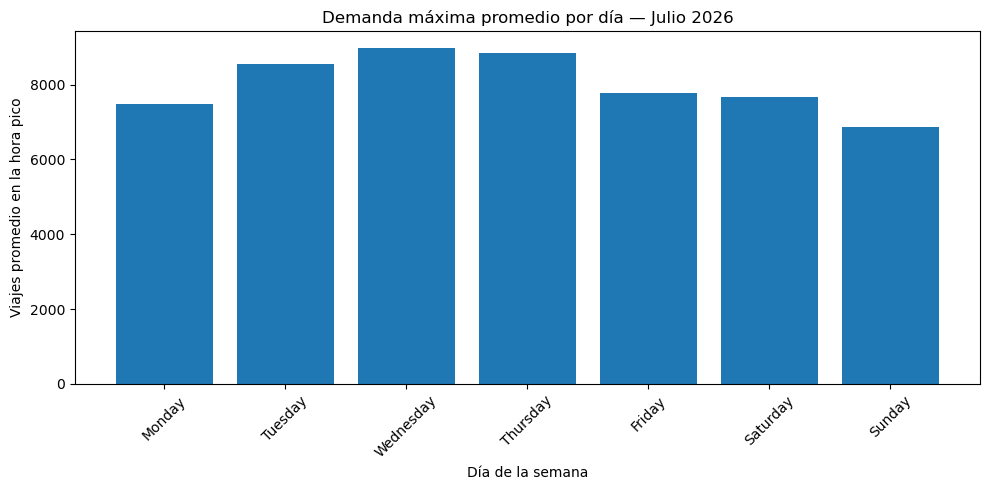

In [18]:
# Visualizar la demanda promedio durante la hora pico de cada d
plt.figure(figsize=(10, 5))

plt.bar(
    resumen_picos.index,
    resumen_picos["viajes_promedio"]
)

plt.title("Demanda máxima promedio por día — Julio 2026")
plt.xlabel("Día de la semana")
plt.ylabel("Viajes promedio en la hora pico")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Interpretación — Demanda máxima por día

La intensidad de la hora pico varía según el día de la semana.

Los mayores niveles de demanda durante la hora pico se observan entre semana, mientras que el fin de semana presenta valores más moderados.

Este análisis complementa la demanda diaria al mostrar no solo qué días tienen más viajes, sino también qué tan intensa es su hora de máxima actividad.


In [19]:
# Comparar la demanda horaria promedio entre días laborales y fines de semana
dias_laborales = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday"
]

fin_de_semana = [
    "Saturday", "Sunday"
]

promedio_laboral = (
    matriz_hora_dia
    .loc[dias_laborales]
    .mean(axis=0)
)

promedio_fin_semana = (
    matriz_hora_dia
    .loc[fin_de_semana]
    .mean(axis=0)
)

comparacion_tipo_dia = pd.DataFrame({
    "Laboral": promedio_laboral,
    "Fin_de_semana": promedio_fin_semana
})

comparacion_tipo_dia.round(0)

,Laboral,Fin_de_semana
pickup_hour,,
0,"2,709.00","6,429.00"
1,"1,501.00","4,944.00"
2,834.00,"3,834.00"
3,579.00,"2,798.00"
4,646.00,"1,968.00"
5,"1,102.00","1,012.00"
6,"2,138.00","1,238.00"
7,"3,684.00","1,512.00"
8,"5,382.00","2,026.00"


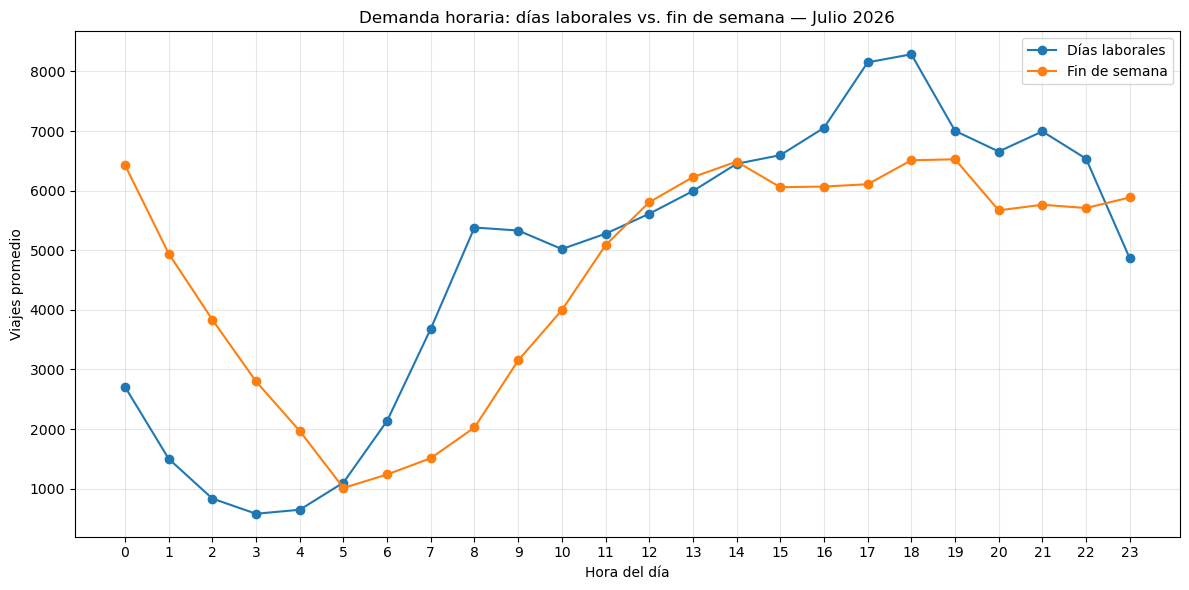

In [20]:
# Visualizar la demanda horaria: días laborales vs. fines de semana
plt.figure(figsize=(12, 6))

plt.plot(
    comparacion_tipo_dia.index,
    comparacion_tipo_dia["Laboral"],
    marker="o",
    label="Días laborales"
)

plt.plot(
    comparacion_tipo_dia.index,
    comparacion_tipo_dia["Fin_de_semana"],
    marker="o",
    label="Fin de semana"
)

plt.title("Demanda horaria: días laborales vs. fin de semana — Julio 2026")
plt.xlabel("Hora del día")
plt.ylabel("Viajes promedio")

plt.xticks(range(24))
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Patrón de demanda: días laborales vs. fines de semana

El análisis horario muestra diferencias claras entre los **días laborales y los fines de semana**.

Durante la madrugada, la demanda es mayor los fines de semana. En cambio, durante la mañana, los días laborales presentan un crecimiento más pronunciado.

En los días laborales, la demanda alcanza su máximo alrededor de las **18:00**, con aproximadamente **8.288 viajes promedio**. Durante el fin de semana, el comportamiento es más estable a lo largo de la tarde y la noche.

A partir de las **20:00**, la demanda de los días laborales comienza a disminuir, mientras que la del fin de semana se mantiene relativamente estable y termina superándola hacia las **23:00**.

In [21]:
# Preparar los datos para analizar la distancia y duración de los viajes
resumen_distancia_duracion = []

for i in range(archivo.metadata.num_row_groups):

    bloque = archivo.read_row_group(
        i,
        columns=[
            "tpep_pickup_datetime",
            "trip_distance",
            "trip_duration_min",
            "flag_quality_issue"
        ]
    ).to_pandas()

    # Mantener solamente julio de 2026
    mascara_julio = (
        (bloque["tpep_pickup_datetime"] >= "2026-07-01") &
        (bloque["tpep_pickup_datetime"] < "2026-08-01")
    )

    bloque = bloque.loc[mascara_julio]

    resumen_distancia_duracion.append(
        bloque[
            [
                "trip_distance",
                "trip_duration_min",
                "flag_quality_issue"
            ]
        ]
    )

    del bloque
    gc.collect()

datos_movilidad = pd.concat(
    resumen_distancia_duracion,
    ignore_index=True
)

datos_movilidad[
    ["trip_distance", "trip_duration_min"]
].describe()

,trip_distance,trip_duration_min
count,"3,530,063.00","3,530,063.00"
mean,5.55,17.29
std,576.21,27.07
min,0.00,-0.17
25%,1.03,8.48
50%,1.90,14.17
75%,3.94,22.17
max,"318,129.10","17,165.42"


In [22]:
# Filtrar los viajes válidos y analizar su distancia y duración
datos_validos = datos_movilidad[
    datos_movilidad["flag_quality_issue"] == False
]

datos_validos[
    ["trip_distance", "trip_duration_min"]
].describe()

,trip_distance,trip_duration_min
count,"3,359,573.00","3,359,573.00"
mean,3.57,17.24
std,4.33,12.34
min,0.01,0.02
25%,1.11,8.73
50%,2.00,14.30
75%,4.10,22.23
max,99.60,179.92


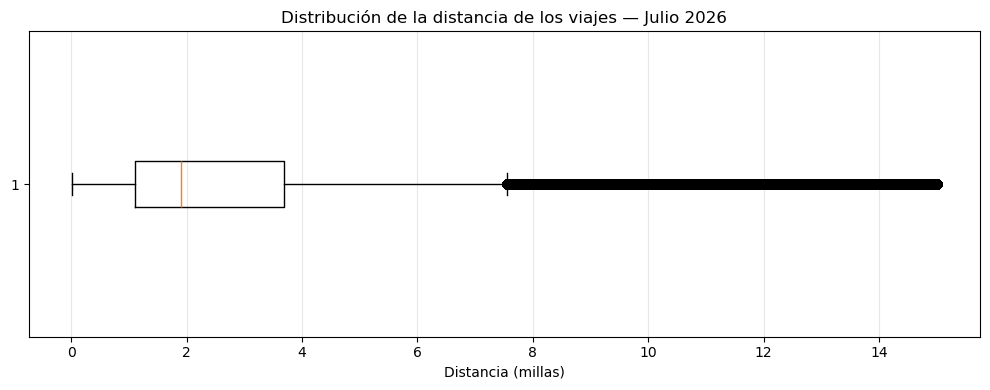

In [23]:
# Visualizar la distribución de la distancia de los viajes válidos
plt.figure(figsize=(10, 4))

plt.boxplot(
    datos_validos.loc[
        datos_validos["trip_distance"] <= 15,
        "trip_distance"
    ],
    vert=False
)

plt.title("Distribución de la distancia de los viajes — Julio 2026")
plt.xlabel("Distancia (millas)")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

### Distribución de la distancia de los viajes

La distribución presenta una **asimetría hacia la derecha**, indicando que la mayoría de los viajes recorren distancias relativamente cortas, mientras que una menor cantidad alcanza distancias mayores.

La **mediana es de 2,00 millas** y el 50 % central de los viajes se concentra entre **1,11 y 4,10 millas**, con un **IQR de 2,99 millas**.

El boxplot también muestra numerosos valores fuera de los límites de los bigotes. Estos representan **posibles outliers estadísticos**, pero no necesariamente registros erróneos, ya que algunos pueden corresponder a viajes legítimamente largos.

In [24]:
# Preparar los datos económicos para analizar ingresos y propinas
datos_economicos_bloques = []

for i in range(archivo.metadata.num_row_groups):

    bloque = archivo.read_row_group(
        i,
        columns=[
            "tpep_pickup_datetime",
            "total_amount",
            "tip_amount",
            "tip_percentage",
            "flag_quality_issue"
        ]
    ).to_pandas()

    # Solo julio de 2026
    mascara_julio = (
        (bloque["tpep_pickup_datetime"] >= "2026-07-01") &
        (bloque["tpep_pickup_datetime"] < "2026-08-01")
    )

    # Solo registros sin problemas de calidad detectados
    bloque = bloque.loc[
        mascara_julio &
        (bloque["flag_quality_issue"] == False)
    ]

    datos_economicos_bloques.append(
        bloque[
            ["total_amount", "tip_amount", "tip_percentage"]
        ]
    )

    del bloque
    gc.collect()

datos_economicos = pd.concat(
    datos_economicos_bloques,
    ignore_index=True
)

datos_economicos.describe()

,total_amount,tip_amount,tip_percentage
count,"3,359,573.00","3,359,573.00","3,346,199.00"
mean,29.89,2.84,11.27
std,22.16,3.97,13.92
min,-671.99,-80.00,0.00
25%,17.35,0.00,0.00
50%,23.49,2.00,12.48
75%,33.94,4.00,20.00
max,720.84,202.00,"9,999.00"


In [25]:
# Revisar posibles anomalías en montos y propinas
print(
    "Total amount negativo:",
    (datos_economicos["total_amount"] < 0).sum()
)

print(
    "Tip amount negativo:",
    (datos_economicos["tip_amount"] < 0).sum()
)

print(
    "Tip percentage > 100%:",
    (datos_economicos["tip_percentage"] > 100).sum()
)

Total amount negativo: 12999
Tip amount negativo: 259
Tip percentage > 100%: 1665


In [26]:
# Filtrar los registros económicos válidos para el análisis
datos_economicos_validos = datos_economicos[
    (datos_economicos["total_amount"] > 0) &
    (datos_economicos["tip_amount"] >= 0) &
    (datos_economicos["tip_percentage"].between(0, 100))
].copy()

print("Registros antes:", len(datos_economicos))
print("Registros después:", len(datos_economicos_validos))
print(
    "Registros excluidos:",
    len(datos_economicos) - len(datos_economicos_validos)
)

Registros antes: 3359573
Registros después: 3344534
Registros excluidos: 15039


### Filtrado para el análisis económico

Los registros excluidos representan aproximadamente el **0,45 % del total**, por lo que se conserva cerca del **99,55 % de los datos** para el análisis económico.

Los **15.039 registros excluidos no fueron eliminados del dataset original**. Simplemente se dejaron fuera de determinadas métricas económicas debido a valores que no cumplen con los criterios definidos para este análisis.

In [27]:
# Obtener el resumen estadístico de las variables económicas
datos_economicos_validos[
    ["total_amount", "tip_amount", "tip_percentage"]
].describe()

,total_amount,tip_amount,tip_percentage
count,"3,344,534.00","3,344,534.00","3,344,534.00"
mean,30.12,2.83,11.18
std,21.77,3.87,10.33
min,1.00,0.00,0.00
25%,17.45,0.00,0.00
50%,23.57,2.00,12.42
75%,33.95,4.00,20.00
max,720.84,112.00,100.00


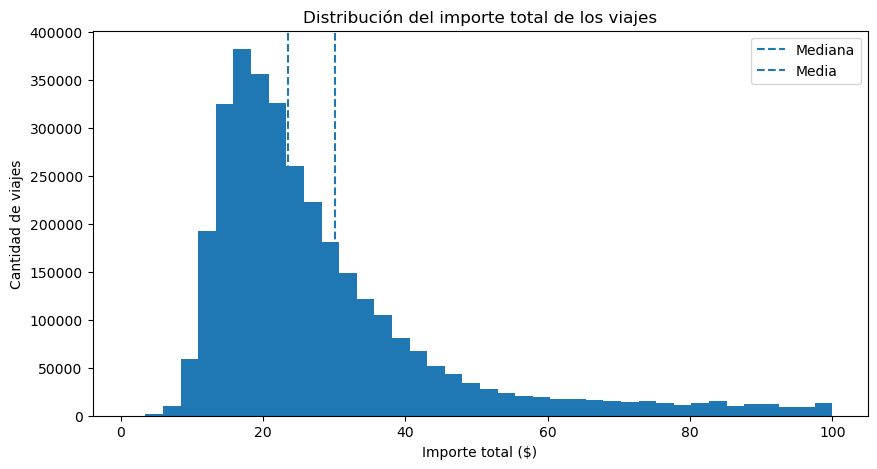

In [28]:
# Visualizar la distribución del importe total de los viajes
datos_grafico = datos_economicos_validos[
    datos_economicos_validos["total_amount"] <= 100
]

plt.figure(figsize=(10, 5))

plt.hist(
    datos_grafico["total_amount"],
    bins=40
)

plt.axvline(
    datos_economicos_validos["total_amount"].median(),
    linestyle="--",
    label="Mediana"
)

plt.axvline(
    datos_economicos_validos["total_amount"].mean(),
    linestyle="--",
    label="Media"
)

plt.title("Distribución del importe total de los viajes")
plt.xlabel("Importe total ($)")
plt.ylabel("Cantidad de viajes")
plt.legend()

plt.show()

### Conclusión del análisis económico

La distribución del importe total presenta una asimetría positiva, con una mayor concentración de viajes en importes relativamente bajos y una cola que se extiende hacia valores más elevados.

La mediana del importe total es de 23,57 USD, mientras que la media es de 30,12 USD. Esta diferencia es consistente con la presencia de importes altos que desplazan la media hacia la derecha.

Para visualizar con mayor claridad la distribución principal, el histograma se limitó a importes de hasta 100 USD. Este límite se aplicó únicamente con fines de visualización y no implica la eliminación de esos registros del dataset original.

In [29]:
# Verificar columnas de origen y destino
import pyarrow.parquet as pq

archivo = pq.ParquetFile(
    "../data/processed/yellow_tripdata_2026-07_features.parquet"
)

[
    columna
    for columna in archivo.schema.names
    if "LocationID" in columna
]

['PULocationID', 'DOLocationID']

In [30]:
# Top 10 LocationID de origen por cantidad de viajes
import pandas as pd

conteo_origen = pd.Series(dtype="int64")

for i in range(archivo.num_row_groups):
    
    bloque = archivo.read_row_group(
        i,
        columns=["PULocationID"]
    ).to_pandas()

    conteo_bloque = bloque["PULocationID"].value_counts()

    conteo_origen = conteo_origen.add(
        conteo_bloque,
        fill_value=0
    )

top10_origen = (
    conteo_origen
    .sort_values(ascending=False)
    .head(10)
    .astype(int)
)

top10_origen

PULocationID
161    152735
132    151817
237    140424
236    118463
186    117792
162    113562
230    108790
170     97766
142     97600
68      96838
dtype: int64

In [31]:
# Cargar catálogo de zonas de NYC
zonas = pd.read_csv("../data/raw/taxi_zone_lookup.csv")

print("Dimensiones:", zonas.shape)

zonas.head()

Dimensiones: (265, 4)


,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


In [32]:
# Convertir Top 10 de origen en DataFrame
top10_origen_df = (
    top10_origen
    .rename("cantidad_viajes")
    .reset_index()
)

# Unir con el catálogo de zonas

top10_origen_df = top10_origen_df.merge(
    zonas,
    left_on="PULocationID",
    right_on="LocationID",
    how="left"
)

# Mostrar las columnas más importantes

top10_origen_df[
    ["PULocationID", "Borough", "Zone", "cantidad_viajes"]
]

,PULocationID,Borough,Zone,cantidad_viajes
0,161,Manhattan,Midtown Center,152735
1,132,Queens,JFK Airport,151817
2,237,Manhattan,Upper East Side South,140424
3,236,Manhattan,Upper East Side North,118463
4,186,Manhattan,Penn Station/Madison Sq West,117792
5,162,Manhattan,Midtown East,113562
6,230,Manhattan,Times Sq/Theatre District,108790
7,170,Manhattan,Murray Hill,97766
8,142,Manhattan,Lincoln Square East,97600
9,68,Manhattan,East Chelsea,96838


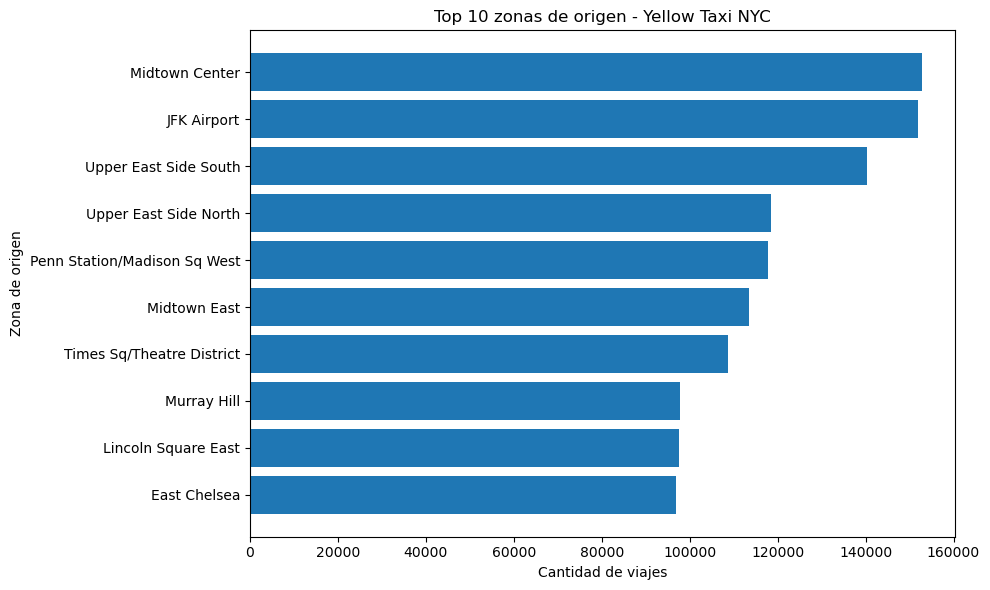

In [33]:
import matplotlib.pyplot as plt

grafico_origen = top10_origen_df.sort_values(
    "cantidad_viajes",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    grafico_origen["Zone"],
    grafico_origen["cantidad_viajes"]
)

plt.title("Top 10 zonas de origen - Yellow Taxi NYC")
plt.xlabel("Cantidad de viajes")
plt.ylabel("Zona de origen")

plt.tight_layout()
plt.show()

### Conclusión — Zonas de origen

Las zonas con mayor cantidad de viajes presentan una distribución relativamente gradual, sin que una única zona concentre ampliamente la demanda. Midtown Center lidera con 152.735 viajes, seguido muy de cerca por JFK Airport con 151.817.

Además, 9 de las 10 principales zonas de origen se encuentran en Manhattan, lo que evidencia una importante concentración de los principales puntos de inicio de viaje en este borough durante julio de 2026.

In [34]:
# Identificar los 10 LocationID de destino con mayor cantidad de viajes
conteo_destino = pd.Series(dtype="int64")

for i in range(archivo.num_row_groups):

    bloque = archivo.read_row_group(
        i,
        columns=["DOLocationID"]
    ).to_pandas()

    conteo_bloque = bloque["DOLocationID"].value_counts()

    conteo_destino = conteo_destino.add(
        conteo_bloque,
        fill_value=0
    )

top10_destino = (
    conteo_destino
    .sort_values(ascending=False)
    .head(10)
    .astype(int)
)

top10_destino

DOLocationID
161    128240
237    125276
236    121600
230    108632
162    100641
170    100630
68      92584
142     86982
239     85331
48      84327
dtype: int64

In [35]:
# Convertir el Top 10 de destinos en un DataFrame
top10_destino_df = (
    top10_destino
    .rename("cantidad_viajes")
    .reset_index()
)

# Incorporar la información geográfica de cada zona
top10_destino_df = top10_destino_df.merge(
    zonas,
    left_on="DOLocationID",
    right_on="LocationID",
    how="left"
)

# Mostrar las variables relevantes
top10_destino_df[
    ["DOLocationID", "Borough", "Zone", "cantidad_viajes"]
]


,DOLocationID,Borough,Zone,cantidad_viajes
0,161,Manhattan,Midtown Center,128240
1,237,Manhattan,Upper East Side South,125276
2,236,Manhattan,Upper East Side North,121600
3,230,Manhattan,Times Sq/Theatre District,108632
4,162,Manhattan,Midtown East,100641
5,170,Manhattan,Murray Hill,100630
6,68,Manhattan,East Chelsea,92584
7,142,Manhattan,Lincoln Square East,86982
8,239,Manhattan,Upper West Side South,85331
9,48,Manhattan,Clinton East,84327


In [36]:
# Comparar la cantidad de viajes entre las principales zonas de origen y destino
comparacion_zonas = pd.merge(
    top10_origen_df[["Zone", "cantidad_viajes"]],
    top10_destino_df[["Zone", "cantidad_viajes"]],
    on="Zone",
    how="outer",
    suffixes=("_origen", "_destino")
).fillna(0)

# Convertir los conteos de viajes a números enteros
comparacion_zonas[
    ["cantidad_viajes_origen", "cantidad_viajes_destino"]
] = comparacion_zonas[
    ["cantidad_viajes_origen", "cantidad_viajes_destino"]
].astype(int)

# Calcular la diferencia entre viajes de origen y destino
comparacion_zonas["diferencia"] = (
    comparacion_zonas["cantidad_viajes_origen"]
    - comparacion_zonas["cantidad_viajes_destino"]
)

# Ordenar las zonas según la cantidad de viajes de origen
comparacion_zonas.sort_values(
    "cantidad_viajes_origen",
    ascending=False
)

,Zone,cantidad_viajes_origen,cantidad_viajes_destino,diferencia
4,Midtown Center,152735,128240,24495
2,JFK Airport,151817,0,151817
10,Upper East Side South,140424,125276,15148
9,Upper East Side North,118463,121600,-3137
7,Penn Station/Madison Sq West,117792,0,117792
5,Midtown East,113562,100641,12921
8,Times Sq/Theatre District,108790,108632,158
6,Murray Hill,97766,100630,-2864
3,Lincoln Square East,97600,86982,10618
1,East Chelsea,96838,92584,4254


In [37]:
# Comparar los viajes de origen y destino en las principales zonas
zonas_principales = pd.concat([
    top10_origen_df[["LocationID", "Zone"]],
    top10_destino_df[["LocationID", "Zone"]]
]).drop_duplicates()

zonas_principales["viajes_origen"] = (
    zonas_principales["LocationID"]
    .map(conteo_origen)
    .fillna(0)
    .astype(int)
)

zonas_principales["viajes_destino"] = (
    zonas_principales["LocationID"]
    .map(conteo_destino)
    .fillna(0)
    .astype(int)
)

zonas_principales["diferencia"] = (
    zonas_principales["viajes_origen"]
    - zonas_principales["viajes_destino"]
)

comparacion_real = zonas_principales.sort_values(
    "viajes_origen",
    ascending=False
)

comparacion_real

,LocationID,Zone,viajes_origen,viajes_destino,diferencia
0,161,Midtown Center,152735,128240,24495
1,132,JFK Airport,151817,33268,118549
2,237,Upper East Side South,140424,125276,15148
3,236,Upper East Side North,118463,121600,-3137
4,186,Penn Station/Madison Sq West,117792,79918,37874
5,162,Midtown East,113562,100641,12921
6,230,Times Sq/Theatre District,108790,108632,158
7,170,Murray Hill,97766,100630,-2864
8,142,Lincoln Square East,97600,86982,10618
9,68,East Chelsea,96838,92584,4254


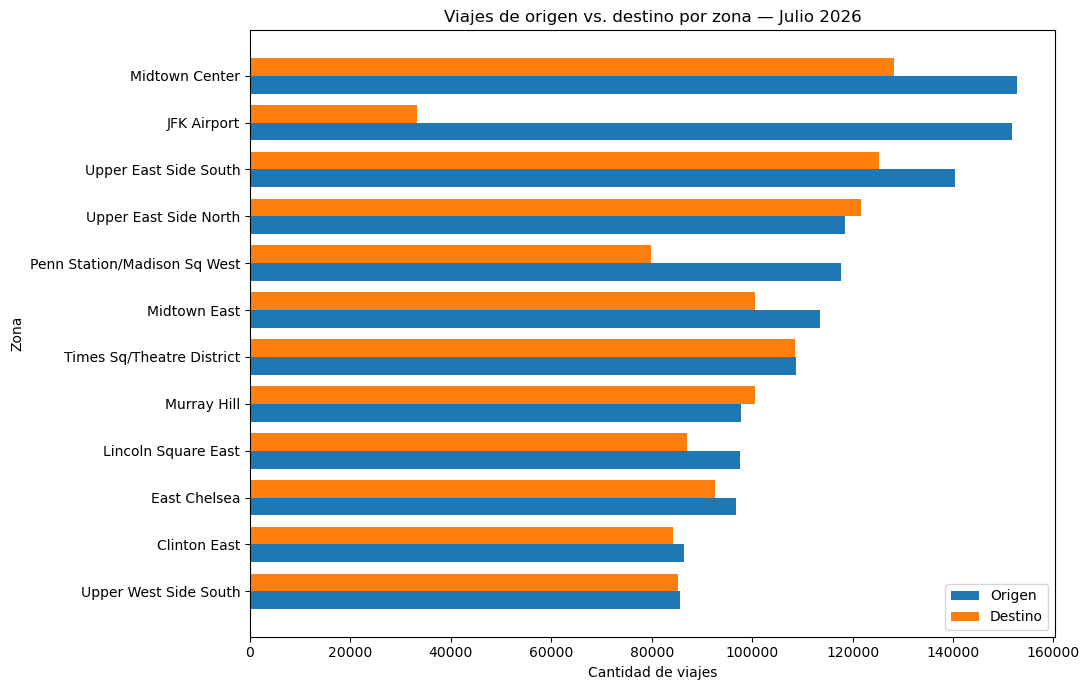

In [38]:
# Visualizar la comparación de viajes de origen y destino por zona
grafico_zonas = comparacion_real.sort_values(
    "viajes_origen",
    ascending=True
)

y = np.arange(len(grafico_zonas))
altura = 0.38

plt.figure(figsize=(11, 7))

plt.barh(
    y - altura / 2,
    grafico_zonas["viajes_origen"],
    height=altura,
    label="Origen"
)

plt.barh(
    y + altura / 2,
    grafico_zonas["viajes_destino"],
    height=altura,
    label="Destino"
)

plt.yticks(
    y,
    grafico_zonas["Zone"]
)

plt.title("Viajes de origen vs. destino por zona — Julio 2026")
plt.xlabel("Cantidad de viajes")
plt.ylabel("Zona")
plt.legend()

plt.tight_layout()
plt.show()

### Interpretación — Origen vs. destino

La comparación muestra que varias zonas presentan volúmenes similares de viajes de origen y destino, mientras que otras muestran diferencias más marcadas.

JFK Airport destaca claramente por registrar muchos más viajes de origen que de destino. Penn Station/Madison Sq West también presenta una mayor cantidad de viajes de salida.

En cambio, zonas como Times Sq/Theatre District muestran un comportamiento prácticamente equilibrado entre ambos tipos de viaje.

In [39]:
# Calcular el balance porcentual entre viajes de origen y destino por zona
comparacion_real["balance_pct"] = (
    (comparacion_real["viajes_origen"] - comparacion_real["viajes_destino"])
    /
    (comparacion_real["viajes_origen"] + comparacion_real["viajes_destino"])
    * 100
)

comparacion_real[
    ["Zone", "viajes_origen", "viajes_destino", "diferencia", "balance_pct"]
].sort_values(
    "balance_pct",
    ascending=False
)

,Zone,viajes_origen,viajes_destino,diferencia,balance_pct
1,JFK Airport,151817,33268,118549,64.05
4,Penn Station/Madison Sq West,117792,79918,37874,19.16
0,Midtown Center,152735,128240,24495,8.72
5,Midtown East,113562,100641,12921,6.03
8,Lincoln Square East,97600,86982,10618,5.75
2,Upper East Side South,140424,125276,15148,5.70
9,East Chelsea,96838,92584,4254,2.25
9,Clinton East,86489,84327,2162,1.27
8,Upper West Side South,85715,85331,384,0.22
6,Times Sq/Theatre District,108790,108632,158,0.07


### Conclusión — Origen vs. destino

El análisis muestra diferencias importantes en el balance entre viajes de origen y destino de las principales zonas.

JFK Airport presenta el mayor desequilibrio, con 151.817 viajes de origen frente a 33.268 de destino y un balance de +64,05%. Penn Station/Madison Sq West también registra una mayor concentración de viajes de origen, con un balance de +19,16%.

En contraste, zonas como Times Sq/Theatre District (+0,07%) y Upper West Side South (+0,22%) presentan volúmenes prácticamente equilibrados entre origen y destino. Upper East Side North (-1,31%) y Murray Hill (-1,44%) muestran una ligera predominancia de destinos.

Estos resultados describen el comportamiento observado en los registros de Yellow Taxi durante julio de 2026 y no permiten, por sí solos, determinar las causas de estas diferencias.

In [40]:
# Calcular la participación porcentual de las principales zonas de origen
total_viajes = conteo_origen.sum()

top10_origen_df["participacion_pct"] = (
    top10_origen_df["cantidad_viajes"]
    / total_viajes
    * 100
)

top10_origen_df[
    ["Zone", "cantidad_viajes", "participacion_pct"]
]

,Zone,cantidad_viajes,participacion_pct
0,Midtown Center,152735,4.33
1,JFK Airport,151817,4.30
2,Upper East Side South,140424,3.98
3,Upper East Side North,118463,3.36
4,Penn Station/Madison Sq West,117792,3.34
5,Midtown East,113562,3.22
6,Times Sq/Theatre District,108790,3.08
7,Murray Hill,97766,2.77
8,Lincoln Square East,97600,2.76
9,East Chelsea,96838,2.74


In [41]:
# Participación conjunta del Top 10

participacion_top10 = (
    top10_origen_df["cantidad_viajes"].sum()
    / total_viajes
    * 100
)

print(f"Participación del Top 10: {participacion_top10:.2f}%")

Participación del Top 10: 33.87%


### Concentración geográfica

Las 10 principales zonas de origen concentran el 33,87% de todos los viajes analizados. Sin embargo, ninguna zona individual supera el 5% del total: Midtown Center representa el 4,33% y JFK Airport el 4,30%.

Esto indica que la demanda no está dominada por una única zona, aunque existe una concentración relevante entre las principales áreas de origen. El 66,13% restante de los viajes se distribuye entre otras zonas.

Dentro del Top 10 de origen, 9 de las 10 zonas pertenecen a Manhattan, mientras que JFK Airport, ubicado en Queens, ocupa la segunda posición.